In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('depression_anxiety_data.csv')
df.head()

,id,school_year,age,gender,bmi,who_bmi,phq_score,depression_severity,depressiveness,suicidal,depression_diagnosis,depression_treatment,gad_score,anxiety_severity,anxiousness,anxiety_diagnosis,anxiety_treatment,epworth_score,sleepiness
0,1,1,19,male,33.333333,Class I Obesity,9,Mild,False,False,False,False,11,Moderate,True,False,False,7.0,False
1,2,1,18,male,19.841270,Normal,8,Mild,False,False,False,False,5,Mild,False,False,False,14.0,True
2,3,1,19,male,25.102391,Overweight,8,Mild,False,False,False,False,6,Mild,False,False,False,6.0,False
3,4,1,18,female,23.738662,Normal,19,Moderately severe,True,True,False,False,15,Severe,True,False,False,11.0,True
4,5,1,18,male,25.617284,Overweight,6,Mild,False,False,False,False,14,Moderate,True,False,False,3.0,False


In [ ]:
df.shape

(783, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    783 non-null    int64  
 1   school_year           783 non-null    int64  
 2   age                   783 non-null    int64  
 3   gender                783 non-null    object 
 4   bmi                   783 non-null    float64
 5   who_bmi               783 non-null    object 
 6   phq_score             783 non-null    int64  
 7   depression_severity   779 non-null    object 
 8   depressiveness        780 non-null    object 
 9   suicidal              782 non-null    object 
 10  depression_diagnosis  782 non-null    object 
 11  depression_treatment  779 non-null    object 
 12  gad_score             783 non-null    int64  
 13  anxiety_severity      783 non-null    object 
 14  anxiousness           777 non-null    object 
 15  anxiety_diagnosis     7

In [ ]:
df.isnull().sum()

,0
id,0
school_year,0
age,0
gender,0
bmi,0
who_bmi,0
phq_score,0
depression_severity,4
depressiveness,3
suicidal,1


In [ ]:
df=df.dropna()

In [ ]:
df.isnull().sum()

,0
id,0
school_year,0
age,0
gender,0
bmi,0
who_bmi,0
phq_score,0
depression_severity,0
depressiveness,0
suicidal,0


In [ ]:
df.shape

(765, 19)

In [ ]:
df = df.drop(['id','anxiety_severity', 'anxiousness', 'anxiety_diagnosis','anxiety_treatment','who_bmi','depression_severity','sleepiness'], axis=1)

In [ ]:
df.columns

Index(['school_year', 'age', 'gender', 'bmi', 'phq_score', 'depressiveness',
       'suicidal', 'depression_diagnosis', 'depression_treatment', 'gad_score',
       'epworth_score'],
      dtype='object')

In [ ]:
num_cols = ['school_year','age','bmi','phq_score','epworth_score']
cat_cols = ['gender','depressiveness','suicidal','depression_diagnosis','depression_treatment']

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop ='first'), cat_cols)
])

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('gad_score', axis=1)
y = df['gad_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()

In [ ]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['school_year', 'age', 'bmi',
                                                   'phq_score',
                                                   'epworth_score']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'depressiveness',
                                                   'suicidal',
                                                   'depression_diagnosis',
                                                   'depression_treatment'])])),
                ('model', LinearRegression())])

In [ ]:
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

n = len(y_test)
p = pipeline.named_steps['preprocessor'].fit_transform(X_train).shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'Adjusted R-squared: {adj_r2:.2f}')

Mean Squared Error: 9.45
R-squared: 0.46
Adjusted R-squared: 0.42


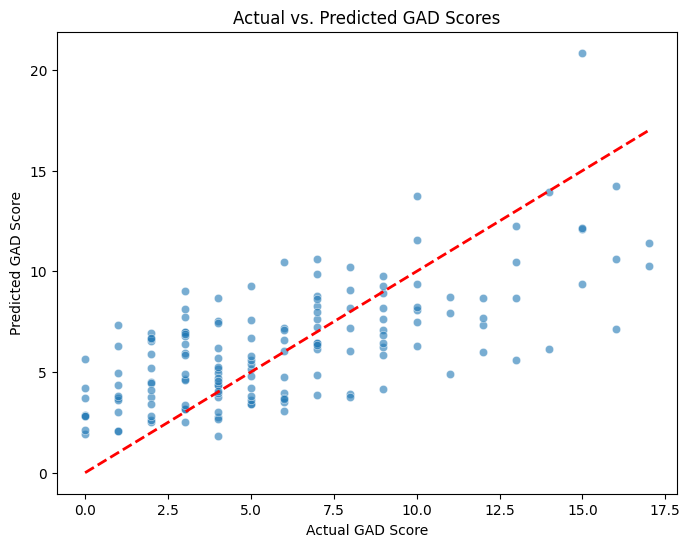

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Perfect prediction line
plt.xlabel('Actual GAD Score')
plt.ylabel('Predicted GAD Score')
plt.title('Actual vs. Predicted GAD Scores')
plt.show()

In [ ]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

coefficients = pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': pd.Series(feature_names).str.replace('num__','').str.replace('cat__',''),
    'Coefficient': coefficients
})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df.reset_index(drop=True, inplace=True)

coef_df

,Feature,Coefficient
0,phq_score,2.929171
1,suicidal_True,0.731093
2,epworth_score,0.671137
3,depression_diagnosis_True,0.483831
4,age,0.286413
5,bmi,0.153060
6,school_year,-0.378550
7,depressiveness_True,-0.450033
8,depression_treatment_True,-0.601396
9,gender_male,-1.273413


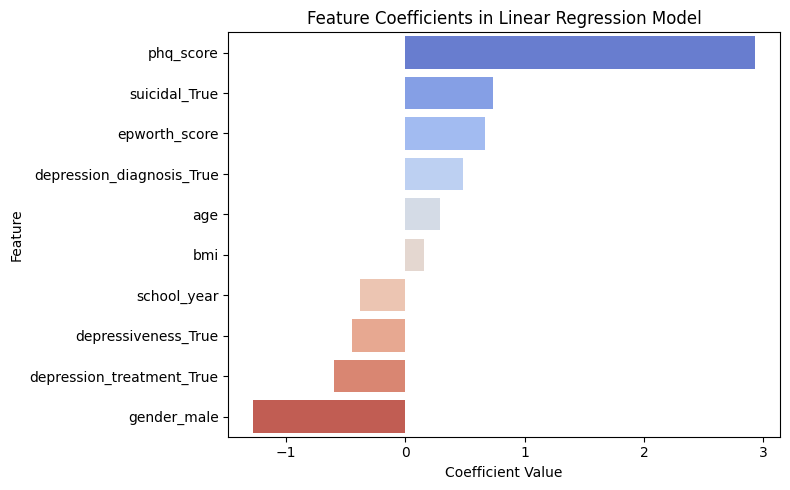

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm', hue='Feature', legend=False)
plt.title('Feature Coefficients in Linear Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()